In [2]:
import pandas as pd

# 读取文本文件
with open(r'C:\Users\owner\Desktop\KG\OneNYC_2050_Strategic_Plan_final.txt', 'r', encoding='utf-8') as file:
    documents_NYC = file.readlines()

# 简单预处理（移除空行）
documents_NYC = [doc.strip() for doc in documents_NYC if doc.strip()]

# 固定节点列表和关键词
fixed_nodes_list = {
    'resilience': ['resilience', 'resilient', 'adaptive capacity', 'toughness', 'durability', 'robustness', 'resiliency', 'recovery ability', 'strength', 'sustainability', 'robust system', 'climate resilience', 'disaster resilience', 'resilient systems', 'adaptive resilience', 'resilience building'],
    'adaptive capacity': ['adaptive','adaptation','adapt', 'adjustment ability', 'adaptation capacity', 'flexibility', 'resilience', 'adaptation', 'coping ability', 'adaptive response', 'climate resilience', 'adaptive management', 'adaptation strategies', 'capacity to adapt', 'system adaptability'],
    'vulnerability assessment': ['vulnerability','vulnerable', 'vulnerability analysis', 'risk assessment', 'impact assessment', 'climate risk evaluation', 'climate vulnerability', 'threat analysis', 'hazard assessment', 'vulnerability mapping', 'climate risk analysis', 'resilience assessment'],
    'climate proofing': ['climate proofing', 'climate resilience', 'climate adaptation', 'climate change adaptation', 'climate resilience strategies', 'climate protection', 'climate-smart infrastructure', 'resilient infrastructure', 'climate adaptation measures', 'climate change mitigation'],
    'ecosystem-based adaptation': ['ecosystem adaptative', 'ecosystem resilience', 'ecosystem change', 'ecosystem', 'ecological adaptation', 'ecosystem response', 'ecological resilience', 'ecosystem transformation', 'environmental adaptation', 'ecosystem sustainability', 'ecosystem-based adaptation', 'ecosystem management'],
    'zoning': ["district", "area management",'urban zoning', 'district policies', 'district regulations', 'zoning codes', 'land use management', 'urban zoning policies', 'spatial zoning'],
    'land use planning': ['land use', 'urban land', 'land development', 'land management', 'land allocation', 'urban land use', 'spatial planning', 'land use policies', 'land planning', 'territorial planning', 'land use zoning', 'land use strategy', 'urban land management', 'land use regulations', 'land use planning policies'],
    'urban design': ['design', 'urban development', 'urban form', 'urban planning', 'built environment', 'renewal', 'city layout', 'urban architecture', 'urban planning design', 'sustainable urban design', 'urban space design', 'landscape'],
    'transportation planning': ['transportation planning', 'public transport', 'transportation', 'transport', 'public transit', 'transport infrastructure', 'transportation systems', 'urban transport'],
    'sustainable development': ['sustainable development', 'sustainability', 'green development', 'sustainable growth', 'eco-friendly development', 'environmental sustainability', 'eco-development', 'green growth', 'environmentally sustainable development', 'sustainable urban development', 'low-carbon development', 'social sustainability', 'economic sustainability', 'sustainability initiatives']
}



In [3]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

# 将两个文档合并为一个列表
documents = documents_NYC

# 创建TF-IDF向量化器
vectorizer = TfidfVectorizer(stop_words='english')

# 计算TF-IDF矩阵
tfidf_matrix = vectorizer.fit_transform(documents)

# 获取词汇表
vocabulary = vectorizer.get_feature_names_out()

# 对每个固定主题，提取对应的词语的TF-IDF权重
topic_weights = {}

for topic, keywords in fixed_nodes_list.items():
    topic_tfidf = []

    # 获取关键词在TF-IDF矩阵中的列索引
    keyword_indices = [vocabulary.tolist().index(keyword) for keyword in keywords if keyword in vocabulary]

    # 提取该主题对应的TF-IDF值
    for idx in keyword_indices:
        tfidf_values = tfidf_matrix[:, idx].toarray().flatten()  # 得到每个文档中该词的TF-IDF值
        topic_tfidf.append(np.mean(tfidf_values))  # 计算该关键词的平均TF-IDF值

    # 计算该主题的总权重（可以根据需要选择合适的方式，比如平均值）
    topic_weights[topic] = np.mean(topic_tfidf)  # 主题权重为其关键词TF-IDF的平均值

# 输出每个主题的权重
for topic, weight in topic_weights.items():
    print(f"Topic: {topic}, Weight: {weight}")

Topic: resilience, Weight: 0.004010406297902805
Topic: adaptive capacity, Weight: 0.0017398149404368617
Topic: vulnerability assessment, Weight: 0.0027193385225025473
Topic: climate proofing, Weight: nan
Topic: ecosystem-based adaptation, Weight: 0.001647978664362286
Topic: zoning, Weight: 0.005350703518424725
Topic: land use planning, Weight: nan
Topic: urban design, Weight: 0.002766071095336189
Topic: transportation planning, Weight: 0.005770548658814
Topic: sustainable development, Weight: 0.005816879694569285


C:\Users\owner\Python\Python311\Lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\owner\Python\Python311\Lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [4]:
topic_weights

{'resilience': 0.004010406297902805,
 'adaptive capacity': 0.0017398149404368617,
 'vulnerability assessment': 0.0027193385225025473,
 'climate proofing': nan,
 'ecosystem-based adaptation': 0.001647978664362286,
 'zoning': 0.005350703518424725,
 'land use planning': nan,
 'urban design': 0.002766071095336189,
 'transportation planning': 0.005770548658814,
 'sustainable development': 0.005816879694569285}

In [5]:
# Ensure values are rounded and formatted to 4 decimal places
V1_rounded = {key: format(value, '.4f') for key, value in topic_weights.items()}

print(V1_rounded)

{'resilience': '0.0040', 'adaptive capacity': '0.0017', 'vulnerability assessment': '0.0027', 'climate proofing': 'nan', 'ecosystem-based adaptation': '0.0016', 'zoning': '0.0054', 'land use planning': 'nan', 'urban design': '0.0028', 'transportation planning': '0.0058', 'sustainable development': '0.0058'}


In [6]:
# 在绘制节点时，提取每个节点对应的大小
sizes = [topic_weights[node] for node in topic_weights]

In [7]:
sizes

[0.004010406297902805,
 0.0017398149404368617,
 0.0027193385225025473,
 nan,
 0.001647978664362286,
 0.005350703518424725,
 nan,
 0.002766071095336189,
 0.005770548658814,
 0.005816879694569285]

     support                                           itemsets
0   0.079914                                (adaptive capacity)
1   0.008639                                 (climate proofing)
2   0.021598                       (ecosystem-based adaptation)
3   0.012959                                (land use planning)
4   0.248380                                       (resilience)
5   0.056156                          (sustainable development)
6   0.168467                          (transportation planning)
7   0.151188                                     (urban design)
8   0.066955                         (vulnerability assessment)
9   0.036717                                           (zoning)
10  0.006479              (adaptive capacity, climate proofing)
11  0.038877                    (resilience, adaptive capacity)
12  0.006479       (sustainable development, adaptive capacity)
13  0.036717       (transportation planning, adaptive capacity)
14  0.017279                  (urban des

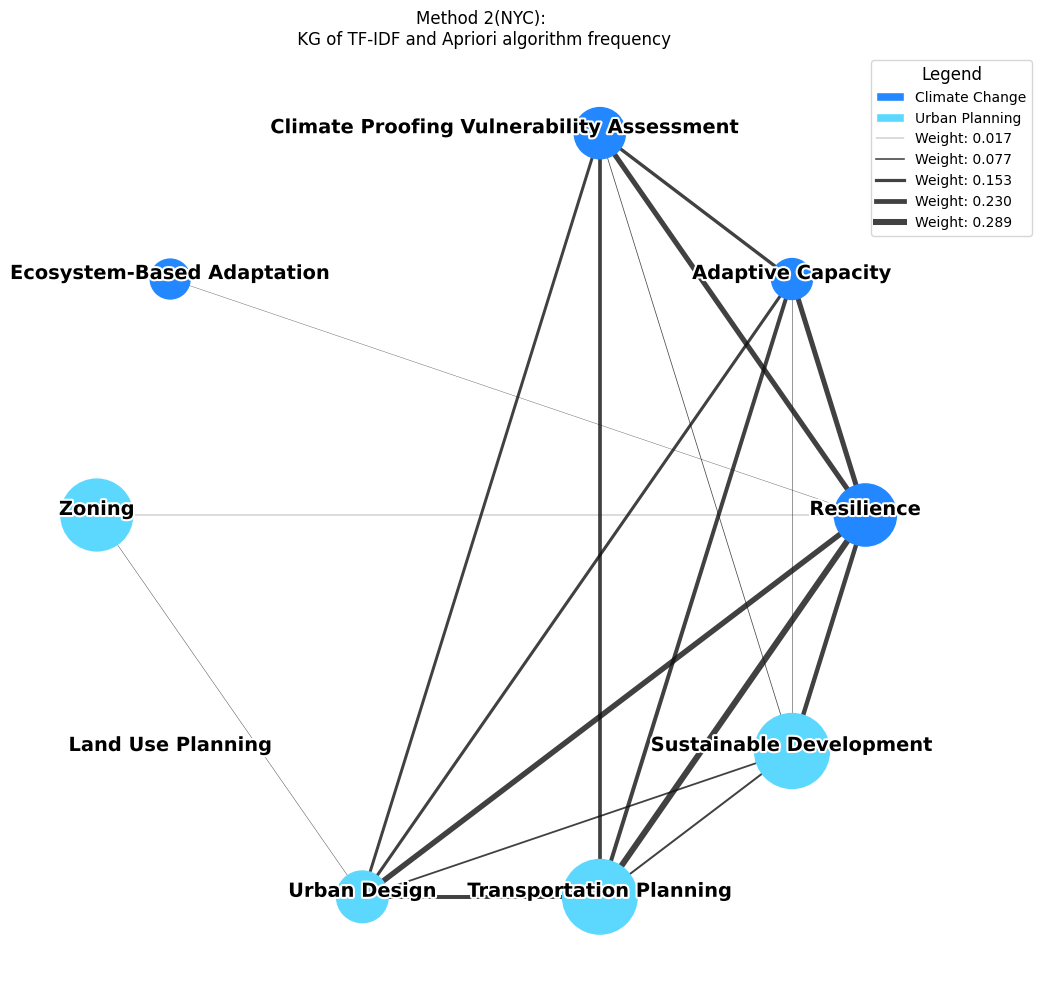

In [8]:
import pandas as pd
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import matplotlib.patheffects as path_effects
# 创建一个字典，存储每个文档中的关键词
document_keywords = []
for doc in documents:
    doc_keywords = set()
    for topic, keywords in fixed_nodes_list.items():
        for keyword in keywords:
            if keyword in doc:
                doc_keywords.add(topic)
    document_keywords.append(list(doc_keywords))

# 使用TransactionEncoder转换文档数据集为0/1矩阵
te = TransactionEncoder()
te_ary = te.fit_transform(document_keywords)

# 转换为DataFrame
df = pd.DataFrame(te_ary, columns=te.columns_)

# 应用Apriori算法找出频繁项集
frequent_itemsets = apriori(df, min_support=0.005, use_colnames=True)

# 生成关联规则
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1,num_itemsets=1000)

# 打印频繁项集和关联规则
print(frequent_itemsets)
print(rules)

# 根据频繁项集构建共现关系图
G = nx.Graph()

# 添加节点
for topic in topic_weights.keys():
    G.add_node(topic)

# 添加边和权重（边的权重即为频繁项集的支持度）
edges = []
weights = []

# 遍历频繁项集并添加边
for _, row in frequent_itemsets.iterrows():
    items = row['itemsets']
    for item1 in items:
        for item2 in items:
            if item1 != item2:
                # 检查边是否已经存在，如果存在则增加权重
                if G.has_edge(item1, item2):
                    G[item1][item2]['weight'] += row['support']
                else:
                    G.add_edge(item1, item2, weight=row['support'])

                # 收集所有边的元组
                edges.append((item1, item2))
                # 收集所有边的支持度作为权重
                weights.append(row['support'])

# 更新边的宽度，以便后续使用，排除权重为0的边
edge_widths = [G[u][v]['weight'] for u, v in edges if G[u][v]['weight'] > 0]
# 打印更新后的边宽度
print("Updated edge widths (non-zero): ", edge_widths)

# 设置阈值，如果节点值小于该值或者是NaN，则删除该节点与其他节点的所有边
threshold = 0.0001
for node, size in zip(topic_weights.keys(), sizes):
    print(f"Node: {node}, Size: {size}")
    if np.isnan(size) or size < threshold:  # 如果节点值为NaN或小于阈值
        print(f"Node {node} is NaN or below threshold")

        # 遍历所有与该节点相连的边，并删除这些边
        for other_node in list(G.neighbors(node)):  # 获取所有相邻的节点
            if G.has_edge(node, other_node):  # 如果存在边
                print(f"Removing edge between {node} and {other_node}")
                G.remove_edge(node, other_node)  # 删除边

# 重新计算所有现存的边
edges = list(G.edges())  # 获取图中现有的所有边

# 更新边的宽度，以便后续使用，排除权重为0的边
edge_widths = [G[u][v]['weight'] for u, v in edges if G[u][v]['weight'] > 0]
# 打印更新后的边宽度
print("Updated edge widths (non-zero): ", edge_widths)


# 圆形布局
pos = nx.circular_layout(G)  # 使用圆形布局
np.random.seed(42)
plt.figure(figsize=(12, 12))
k=500000
# 绘制前五个固定节点（深蓝色，中心较大）
nx.draw_networkx_nodes(
    G,
    pos,
    nodelist=list(fixed_nodes_list.keys())[:5],  # 前五个节点
    node_color="#2388FF",
    node_size=[size * k for size in sizes[:5]],  # 计算前五个节点的大小
    label="climate adaptation"
)

# 绘制剩余的固定节点（浅蓝色，中心较大）
nx.draw_networkx_nodes(
    G,
    pos,
    nodelist=list(fixed_nodes_list.keys())[5:],  # 剩余节点
    node_color="#5CD8FF",
    node_size=[size * k for size in sizes[5:]],  # 计算剩余节点的大小
    label="urban planning"
)
print(f'sizes:{sizes}')
j=15
# 绘制权重大于0的边
nx.draw_networkx_edges(
    G,
    pos,
    width=[edge_width * j for edge_width in edge_widths],  # 使用非零的边宽
    edge_color='#111111',
    alpha=0.8,
)


# 提取边的权重
edges1 = G.edges(data=True)
weights1 = [data['weight'] for _, _, data in edges1]

# 生成用于图例的示例边权重
min_weight, max_weight = min(weights1), max(weights1)

# 不再归一化，直接使用原始权重
example_weights = [min_weight, (min_weight + max_weight) / 4, (min_weight + max_weight) / 2, (min_weight + max_weight) / 4 * 3, max_weight]
example_widths = [min_weight * j, (min_weight + max_weight) / 4 * j, (min_weight + max_weight) / 2 * j, (min_weight + max_weight) / 4 * 3 * j, max_weight * j]

# 绘制标签并首字母大写，添加白色描边
for node, (x, y) in pos.items():
    text = plt.text(
        x, y, node.title(), fontsize=14, fontweight='bold', ha='center', color='black'
    )
    text.set_path_effects([
        path_effects.Stroke(linewidth=3, foreground='white'),  # 添加白色描边
        path_effects.Normal()  # 恢复正常文字效果
    ])
plt.title("Method 2(NYC):\n KG of TF-IDF and Apriori algorithm frequency")
plt.axis('off')

# 添加图例
legend_elements = [
    Patch(facecolor='#2388FF', edgecolor='#ffffff', label='Climate Change'),  # 蓝色固定节点
    Patch(facecolor='#5CD8FF', edgecolor='#ffffff', label='Urban Planning'),   # 黄色固定节点
]

# 添加边权重示例
for w, width in zip(example_weights, example_widths):
    legend_elements.append(
        Line2D(
            [0], [0],
            color='#111111',
            alpha=0.8,
            lw=width,
            label=f"Weight: {w:.3f}"
        )
    )

# 绘制图例
plt.legend(
    handles=legend_elements,
    loc="upper right",
    bbox_to_anchor=(1.1, 1),
    fontsize=10,
    title="Legend",
    title_fontsize=12,
    frameon=True,
)


plt.show()

In [9]:
import pandas as pd
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import matplotlib.patheffects as path_effects
# 创建一个字典，存储每个文档中的关键词
document_keywords = []
for doc in documents:
    doc_keywords = set()
    for topic, keywords in fixed_nodes_list.items():
        for keyword in keywords:
            if keyword in doc:
                doc_keywords.add(topic)
    document_keywords.append(list(doc_keywords))

# 使用TransactionEncoder转换文档数据集为0/1矩阵
te = TransactionEncoder()
te_ary = te.fit_transform(document_keywords)

# 转换为DataFrame
df = pd.DataFrame(te_ary, columns=te.columns_)

# 应用Apriori算法找出频繁项集
frequent_itemsets = apriori(df, min_support=0.005, use_colnames=True)

# 生成关联规则
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1,num_itemsets=1000)

# 打印频繁项集和关联规则
print(frequent_itemsets)
print(rules)

     support                                           itemsets
0   0.079914                                (adaptive capacity)
1   0.008639                                 (climate proofing)
2   0.021598                       (ecosystem-based adaptation)
3   0.012959                                (land use planning)
4   0.248380                                       (resilience)
5   0.056156                          (sustainable development)
6   0.168467                          (transportation planning)
7   0.151188                                     (urban design)
8   0.066955                         (vulnerability assessment)
9   0.036717                                           (zoning)
10  0.006479              (adaptive capacity, climate proofing)
11  0.038877                    (resilience, adaptive capacity)
12  0.006479       (sustainable development, adaptive capacity)
13  0.036717       (transportation planning, adaptive capacity)
14  0.017279                  (urban des

Updated edge widths (non-zero):  [0.24190064794816413, 0.017278617710583154, 0.2116630669546436, 0.2894168466522678, 0.26349892008639303, 0.24622030237580994, 0.017278617710583154, 0.02591792656587473, 0.19006479481641472, 0.1468682505399568, 0.1598272138228942, 0.03455723542116631, 0.17710583153347736, 0.14254859611231102, 0.02159827213822894, 0.08639308855291576, 0.19006479481641472, 0.09503239740820733]
Node: resilience, Size: 0.004010406297902805
Node: adaptive capacity, Size: 0.0017398149404368617
Node: vulnerability assessment, Size: 0.0027193385225025473
Node: climate proofing, Size: nan
Node climate proofing is NaN or below threshold
Removing edge between climate proofing and adaptive capacity
Removing edge between climate proofing and resilience
Node: ecosystem-based adaptation, Size: 0.001647978664362286
Node: zoning, Size: 0.005350703518424725
Node: land use planning, Size: nan
Node land use planning is NaN or below threshold
Removing edge between land use planning and resil

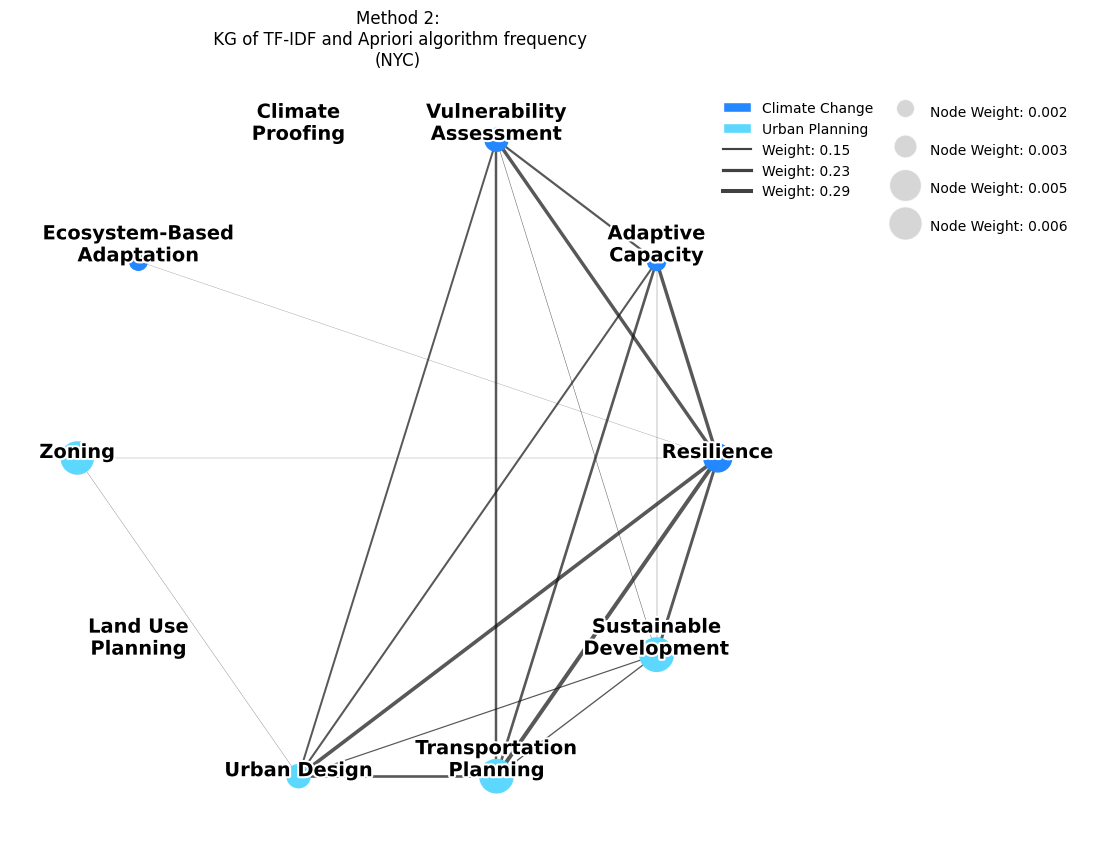

In [13]:
import textwrap
# 根据频繁项集构建共现关系图
G = nx.Graph()

# 添加节点
for topic in topic_weights.keys():
    G.add_node(topic)

# 添加边和权重（边的权重即为频繁项集的支持度）
edges = []
weights = []

# 遍历频繁项集并添加边
for _, row in frequent_itemsets.iterrows():
    items = row['itemsets']
    for item1 in items:
        for item2 in items:
            if item1 != item2:
                # 检查边是否已经存在，如果存在则增加权重
                if G.has_edge(item1, item2):
                    G[item1][item2]['weight'] += row['support']
                else:
                    G.add_edge(item1, item2, weight=row['support'])

                # 收集所有边的元组
                edges.append((item1, item2))
                # 收集所有边的支持度作为权重
                weights.append(row['support'])

# 更新边的宽度，以便后续使用，排除权重为0的边
#edge_widths = [G[u][v]['weight'] for u, v in edges if G[u][v]['weight'] > 0]
# 打印更新后的边宽度
print("Updated edge widths (non-zero): ", edge_widths)

# 设置阈值，如果节点值小于该值或者是NaN，则删除该节点与其他节点的所有边
threshold = 0.0001
for node, size in zip(topic_weights.keys(), sizes):
    print(f"Node: {node}, Size: {size}")
    if np.isnan(size) or size < threshold:  # 如果节点值为NaN或小于阈值
        print(f"Node {node} is NaN or below threshold")

        # 遍历所有与该节点相连的边，并删除这些边
        for other_node in list(G.neighbors(node)):  # 获取所有相邻的节点
            if G.has_edge(node, other_node):  # 如果存在边
                print(f"Removing edge between {node} and {other_node}")
                G.remove_edge(node, other_node)  # 删除边

# 重新计算所有现存的边
edges = list(G.edges())  # 获取图中现有的所有边

# 更新边的宽度，以便后续使用，排除权重为0的边
edge_widths = [G[u][v]['weight'] for u, v in edges if G[u][v]['weight'] > 0]
# 打印更新后的边宽度
print("Updated edge widths (non-zero): ", edge_widths)


# 圆形布局
pos = nx.circular_layout(G)  # 使用圆形布局
np.random.seed(42)
plt.figure(figsize=(10, 10))
k=100000
j=10
#k = 10000
#j=2
# 绘制前五个固定节点（深蓝色，中心较大）
nx.draw_networkx_nodes(
    G,
    pos,
    nodelist=list(fixed_nodes_list.keys())[:5],  # 前五个节点
    node_color="#2388FF",
    node_size=[size * k for size in sizes[:5]],  # 计算前五个节点的大小
    label="climate adaptation"
)

# 绘制剩余的固定节点（浅蓝色，中心较大）
nx.draw_networkx_nodes(
    G,
    pos,
    nodelist=list(fixed_nodes_list.keys())[5:],  # 剩余节点
    node_color="#5CD8FF",
    node_size=[size * k for size in sizes[5:]],  # 计算剩余节点的大小
    label="urban planning"
)
print(f'sizes:{sizes}')
###############

###########
# 绘制权重大于0的边
nx.draw_networkx_edges(
    G,
    pos,
    width=[edge_width * j for edge_width in edge_widths if edge_width >= 0.001],  # 使用非零的边宽
    edge_color='#111111',
    alpha=0.7,
)


# 提取边的权重
edges1 = G.edges(data=True)
weights1 = [data['weight'] for _, _, data in edges1]


# 生成用于图例的示例边权重
min_weight, max_weight = min(weights1), max(weights1)

# 不再归一化，直接使用原始权重
example_weights = [
    min_weight,
    (min_weight + max_weight) / 4,
    (min_weight + max_weight) / 2,
    (min_weight + max_weight) / 4 * 3,
    max_weight
]

example_widths = [
    min_weight * j,
    (min_weight + max_weight) / 4 * j,
    (min_weight + max_weight) / 2 * j,
    (min_weight + max_weight) / 4 * 3 * j,
    max_weight * j
]

# 此时 example_widths 和 example_weights 均为有效的范围

# 绘制标签并首字母大写，添加白色描边
for node, (x, y) in pos.items():
    weight = f"{topic_weights.get(node, 0):.4f}" if topic_weights.get(node, 0) > 0 else "0"
    modified_node = f"{node}"#\n{weight}
    wrapped_text = textwrap.fill(modified_node.title(), width=15)
    text = plt.text(
        x, y, wrapped_text, fontsize=14, fontweight='bold', ha='center', color='black'
    )
    text.set_path_effects([
        path_effects.Stroke(linewidth=3, foreground='white'),  # 添加白色描边
        path_effects.Normal()  # 恢复正常文字效果
    ])


# 添加图例
legend_elements = [
    Patch(facecolor='#2388FF', edgecolor='#ffffff', label='Climate Change'),  # 蓝色固定节点
    Patch(facecolor='#5CD8FF', edgecolor='#ffffff', label='Urban Planning'),   # 黄色固定节点
]
# 调整图例中的节点大小计算
legend_node_sizes = [np.sqrt(size*k) for size in sizes]  # 根据绘图的node_size计算半径
legend_node_weights = [node_weight for node_weight in sizes]

# 对节点权重和大小去重并排序，同时移除 NaN
unique_weights_sizes = sorted(
    {(w, s) for w, s in zip(legend_node_weights, legend_node_sizes) if not np.isnan(w) and not np.isnan(s)}
)
sorted_weights, sorted_sizes = zip(*unique_weights_sizes) if unique_weights_sizes else ([], [])

# 限制图例中最多五个节点，确保头尾都在
max_legend_items = 5

if len(sorted_weights) > max_legend_items:
    # 包含头尾节点
    first_weight, last_weight = sorted_weights[0], sorted_weights[-1]
    first_size, last_size = sorted_sizes[0], sorted_sizes[-1]

    # 从中间节点中等间距选取剩余的节点
    middle_weights = sorted_weights[1:-1]
    middle_sizes = sorted_sizes[1:-1]
    num_middle_items = max_legend_items - 2  # 除去头尾的数量

    if num_middle_items > 0:
        step = max(1, len(middle_weights) // num_middle_items)  # 计算步长
        sampled_indices = list(range(0, len(middle_weights), step))[:num_middle_items]
        middle_weights = [middle_weights[i] for i in sampled_indices]
        middle_sizes = [middle_sizes[i] for i in sampled_indices]
    else:
        middle_weights, middle_sizes = [], []

    # 合并头部、中间和尾部
    sorted_weights =  middle_weights + [last_weight]
    sorted_sizes =  middle_sizes + [last_size]

# 添加边权重示例
for w, width in zip(example_weights[2:], example_widths[2:]):
    legend_elements.append(
        Line2D(
            [0], [0],
            color='#111111',
            alpha=0.8,
            lw=width,
            label=f"Weight: {w:.2f}"
        )
    )

# 添加节点大小图例
node_size_legend = [
    Line2D([0], [0], marker='o', color='w',
           markersize=size,  # 直接使用调整后的半径作为markersize
           markerfacecolor='#CCCCCC',
           alpha=0.8,
           label=f"Node Weight: {weight:.3f}")
    for weight, size in zip(sorted_weights, sorted_sizes)
]
legend_elements.extend(node_size_legend)

# 绘制节点图例
node_legend = plt.legend(
    handles=legend_elements[:5],  # 节点相关图例
    loc="upper right",
    bbox_to_anchor=(1.15, 1),
    fontsize=10,
    frameon=False,
    borderpad=1.5      # 增加边框和内容之间的填充
)
plt.gca().add_artist(node_legend)  # 手动添加第一个图例
# 绘制边权重图例
plt.legend(
    handles=legend_elements[5:],  # 边权重相关图例
    loc="upper right",
    bbox_to_anchor=(1.4, 1),
    fontsize=10,
    frameon=False,
    labelspacing=1.2,  # 增加标签之间的垂直间距
    handleheight=2,    # 增加句柄（marker）高度
    borderpad=1.5      # 增加边框和内容之间的填充
)
plt.title("Method 2:\n KG of TF-IDF and Apriori algorithm frequency\n(NYC)")
plt.axis('off')
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import os
from pydlc import dense_lines
import numpy as np

def plot_cluster_data(file_path,find_id_path, K, output_folder):
    # 读取CSV文件
    data = pd.read_csv(file_path)
    print(data)
    data_id = pd.read_excel(find_id_path, header = None)

    all_ids = []
    all_values = []

    for index, row in data_id.iterrows():
        row_id = row[0]
        values = row[1:].dropna().tolist()
        all_ids.append(row_id)
        all_values.append(values)

    for sum_id, value_list in zip(all_ids, all_values):

        sum_id_data = data[data['Sum ID']== sum_id]
        city = sum_id_data['Place'].iloc[0]
        place_id = sum_id_data['City Name'].iloc[0]
        # 获取所有的 cluster 值
        cluster = sum_id_data['Cluster'].iloc[0]

        cluster_data_to_plot = sum_id_data.iloc[:, 2:-5]

        # 创建图表
        fig, ax = plt.subplots(figsize=(20, 6))
        fig.patch.set_facecolor('white')
        ax.set_facecolor('white')

        # 获取列索引
        columns = np.arange(cluster_data_to_plot.shape[1])

        # 计算统计量
        median = cluster_data_to_plot.median()
        q1 = cluster_data_to_plot.quantile(0)
        q3 = cluster_data_to_plot.quantile(1)

        # 🎨 添加 value_list 折线图（灰色线）
        if len(value_list) == len(columns):
            ax.plot(columns, value_list, color='lightgray', linewidth=1, label='Input Curve (Excel)', zorder=1)

        # 添加中位数曲线
        ax.plot(columns, median, linestyle='-', color='blue', linewidth=2, label='Cluster Median', zorder=10)

        # 添加 IQR 区间
        ax.fill_between(columns, q1, q3, color='orange', alpha=0.3, label='IQR (0% ~ 100%)')

        # 图例和标签
        ax.legend(fontsize=12)
        ax.set_title(f'{city}_{place_id}_sorted_clustered_(K={K})_Cluster {cluster}', fontsize=20)
        ax.set_xlabel('DAY', fontsize=14)
        ax.set_ylabel('slide_TEM', fontsize=14)

        ax.grid(False)
        ax.set_ylim(-12, 12)

        # 设置 X 轴刻度和标签
        ax.set_xticks(columns[::50])  # 每隔50个数据点设置一个刻度
        ax.set_xticklabels(columns[::50])  # 设置对应刻度的标签为 columns 数组中的值

        # 旋转 x 轴标签，避免重叠
        plt.xticks(rotation=90)

        # 设置 x 轴范围，保证宽度匹配 figsize=(20, 6)
        ax.set_xlim(0, len(columns))  # 设置 x 轴范围为 0 到总列数

        # 调整布局，确保图像居中显示
        plt.tight_layout()

        # 保存图像为 JPG 格式
        os.makedirs(output_folder, exist_ok=True)
        output_folder_2 = os.path.join(output_folder)
        os.makedirs(output_folder_2, exist_ok= True)
        output_file = os.path.join(output_folder_2 , rf'{city}_sorted_clustered_som_kmeans_data(K={K})_{cluster}.jpg')
        plt.savefig(output_file, format='jpg', dpi=100, bbox_inches='tight')

        # 显示图表
        plt.show()


K = 11

file_path = rf'D:\file\d_som\223_cities_combined_moving_ave_cluster_sort.csv'
find_id_path = rf'C:\Users\owner\Desktop\Sum ID.xlsx'
output_folder = rf'D:\file\d_som\results\picture\city_abnormal'
os.makedirs(output_folder, exist_ok=True)

plot_cluster_data(file_path,find_id_path, K, output_folder)